
# 주제
## - 한국어 대중음악의 음악적 특성과 Spotify 인기도의 관계 분석

# 분석 질문

## - 인기 있는 한국어 노래는 어떤 음악적 특징을 가지고 있을까?

## - 음악적 특성과 Spotify 인기도 사이에는 어떤 관계가 있을까?

## - 음악적 특성만으로 인기곡과 비인기곡을 구분할 수 있을까?

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("spotify_tracks.csv")

df.head()

,track_id,track_name,artist_name,year,popularity,artwork_url,album_name,acousticness,danceability,duration_ms,...,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,track_url,language
0,2r0ROhr7pRN4MXDMT1fEmd,"Leo Das Entry (From ""Leo"")",Anirudh Ravichander,2024,59,https://i.scdn.co/image/ab67616d0000b273ce9c65...,"Leo Das Entry (From ""Leo"")",0.0241,0.753,97297.0,...,8.0,0.1000,-5.994,0.0,0.1030,110.997,4.0,0.459,https://open.spotify.com/track/2r0ROhr7pRN4MXD...,Tamil
1,4I38e6Dg52a2o2a8i5Q5PW,AAO KILLELLE,"Anirudh Ravichander, Pravin Mani, Vaishali Sri...",2024,47,https://i.scdn.co/image/ab67616d0000b273be1b03...,AAO KILLELLE,0.0851,0.780,207369.0,...,10.0,0.0951,-5.674,0.0,0.0952,164.995,3.0,0.821,https://open.spotify.com/track/4I38e6Dg52a2o2a...,Tamil
2,59NoiRhnom3lTeRFaBzOev,Mayakiriye Sirikiriye - Orchestral EDM,"Anirudh Ravichander, Anivee, Alvin Bruno",2024,35,https://i.scdn.co/image/ab67616d0000b27334a1dd...,Mayakiriye Sirikiriye (Orchestral EDM),0.0311,0.457,82551.0,...,2.0,0.0831,-8.937,0.0,0.1530,169.996,4.0,0.598,https://open.spotify.com/track/59NoiRhnom3lTeR...,Tamil
3,5uUqRQd385pvLxC8JX3tXn,Scene Ah Scene Ah - Experimental EDM Mix,"Anirudh Ravichander, Bharath Sankar, Kabilan, ...",2024,24,https://i.scdn.co/image/ab67616d0000b27332e623...,Scene Ah Scene Ah (Experimental EDM Mix),0.2270,0.718,115831.0,...,7.0,0.1240,-11.104,1.0,0.4450,169.996,4.0,0.362,https://open.spotify.com/track/5uUqRQd385pvLxC...,Tamil
4,1KaBRg2xgNeCljmyxBH1mo,Gundellonaa X I Am A Disco Dancer - Mashup,"Anirudh Ravichander, Benny Dayal, Leon James, ...",2024,22,https://i.scdn.co/image/ab67616d0000b2735a59b6...,Gundellonaa X I Am a Disco Dancer (Mashup),0.0153,0.689,129621.0,...,7.0,0.3450,-9.637,1.0,0.1580,128.961,4.0,0.593,https://open.spotify.com/track/1KaBRg2xgNeCljm...,Tamil


In [5]:
df.shape

(62317, 22)

In [6]:
df.columns.tolist()

['track_id',
 'track_name',
 'artist_name',
 'year',
 'popularity',
 'artwork_url',
 'album_name',
 'acousticness',
 'danceability',
 'duration_ms',
 'energy',
 'instrumentalness',
 'key',
 'liveness',
 'loudness',
 'mode',
 'speechiness',
 'tempo',
 'time_signature',
 'valence',
 'track_url',
 'language']

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 62317 entries, 0 to 62316
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          62317 non-null  str    
 1   track_name        62317 non-null  str    
 2   artist_name       62317 non-null  str    
 3   year              62317 non-null  int64  
 4   popularity        62317 non-null  int64  
 5   artwork_url       62317 non-null  str    
 6   album_name        62317 non-null  str    
 7   acousticness      62317 non-null  float64
 8   danceability      62317 non-null  float64
 9   duration_ms       62317 non-null  float64
 10  energy            62317 non-null  float64
 11  instrumentalness  62317 non-null  float64
 12  key               62317 non-null  float64
 13  liveness          62317 non-null  float64
 14  loudness          62317 non-null  float64
 15  mode              62317 non-null  float64
 16  speechiness       62317 non-null  float64
 17  temp

In [8]:
df.isna().sum()

track_id            0
track_name          0
artist_name         0
year                0
popularity          0
artwork_url         0
album_name          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
track_url           0
language            0
dtype: int64

In [9]:
df["track_id"].duplicated().sum()

np.int64(78)

In [10]:
duplicate_ids = df["track_id"].value_counts()

duplicate_ids = duplicate_ids[duplicate_ids > 1]

duplicate_ids

track_id
50RcuWjfUcoJfWMNegXF0b    2
5zDRx2IlpoiNHBpmG4btVN    2
3huCRjAX12zNPxtX9JqX2X    2
21r0QnhYxsxYUsoov5o0IF    2
42LMjL86cep0L8QA1q0doE    2
                         ..
2sYIrPDAeu3i9vlVrofwvh    2
0DqKN7Wg0lsQaf6MuaREpX    2
7jSXMBdFfshfffYQmWWbHz    2
6DVTHHdDFEnL9UcDaLSCvg    2
08elXSPBnP9uFYkjpObT5T    2
Name: count, Length: 78, dtype: int64

In [11]:
duplicate_df = df[
    df["track_id"].isin(duplicate_ids.index)
].sort_values("track_id")

duplicate_df.head(20)

,track_id,track_name,artist_name,year,popularity,artwork_url,album_name,acousticness,danceability,duration_ms,...,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,track_url,language
2494,08elXSPBnP9uFYkjpObT5T,"Yaaro Ucchikilai Meley (From ""Taramani"")",Yuvan Shankar Raja,2020,0,https://i.scdn.co/image/ab67616d0000b27320428b...,U1 For Life,0.02170,0.643,177867.0,...,8.0,0.1460,-5.697,0.0,0.0510,179.991,4.0,0.5090,https://open.spotify.com/track/08elXSPBnP9uFYk...,Tamil
2572,08elXSPBnP9uFYkjpObT5T,"Yaaro Ucchikilai Meley (From ""Taramani"")",Yuvan Shankar Raja,2020,0,https://i.scdn.co/image/ab67616d0000b27320428b...,U1 For Life,0.02170,0.643,177867.0,...,8.0,0.1460,-5.697,0.0,0.0510,179.991,4.0,0.5090,https://open.spotify.com/track/08elXSPBnP9uFYk...,Tamil
2432,0A0fukU8m9V1DHzzIOFUHq,"Ye Rasa - From ""MaaManithan""","Yuvan Shankar Raja, Ilayaraaja, U1 Records",2021,35,https://i.scdn.co/image/ab67616d0000b2738bc6a0...,"Ye Rasa (From ""MaaManithan"")",0.72600,0.702,242659.0,...,9.0,0.0731,-7.922,1.0,0.0323,125.990,3.0,0.4120,https://open.spotify.com/track/0A0fukU8m9V1DHz...,Tamil
2510,0A0fukU8m9V1DHzzIOFUHq,"Ye Rasa - From ""MaaManithan""","Yuvan Shankar Raja, Ilayaraaja, U1 Records",2021,35,https://i.scdn.co/image/ab67616d0000b2738bc6a0...,"Ye Rasa (From ""MaaManithan"")",0.72600,0.702,242659.0,...,9.0,0.0731,-7.922,1.0,0.0323,125.990,3.0,0.4120,https://open.spotify.com/track/0A0fukU8m9V1DHz...,Tamil
2491,0DqKN7Wg0lsQaf6MuaREpX,Munnala Ninna Pothum,"Yuvan Shankar Raja, Saindhavi, Sunandan",2020,4,https://i.scdn.co/image/ab67616d0000b2734ae5bd...,Dabangg 3,0.27000,0.496,246625.0,...,9.0,0.1390,-3.419,1.0,0.1120,128.921,4.0,0.8480,https://open.spotify.com/track/0DqKN7Wg0lsQaf6...,Tamil
2569,0DqKN7Wg0lsQaf6MuaREpX,Munnala Ninna Pothum,"Yuvan Shankar Raja, Saindhavi, Sunandan",2020,4,https://i.scdn.co/image/ab67616d0000b2734ae5bd...,Dabangg 3,0.27000,0.496,246625.0,...,9.0,0.1390,-3.419,1.0,0.1120,128.921,4.0,0.8480,https://open.spotify.com/track/0DqKN7Wg0lsQaf6...,Tamil
2453,0KwvFKhnCX8KNlxPyoqSB3,One On One,"Yuvan Shankar Raja, Vivek - Mervin",2021,8,https://i.scdn.co/image/ab67616d0000b273e3d93e...,Sulthan (Original Background Score),0.48500,0.448,72042.0,...,8.0,0.1490,-12.078,1.0,0.0341,69.793,4.0,0.5310,https://open.spotify.com/track/0KwvFKhnCX8KNlx...,Tamil
2531,0KwvFKhnCX8KNlxPyoqSB3,One On One,"Yuvan Shankar Raja, Vivek - Mervin",2021,8,https://i.scdn.co/image/ab67616d0000b273e3d93e...,Sulthan (Original Background Score),0.48500,0.448,72042.0,...,8.0,0.1490,-12.078,1.0,0.0341,69.793,4.0,0.5310,https://open.spotify.com/track/0KwvFKhnCX8KNlx...,Tamil
2455,0N8lYKVw037rT75VMb5u0m,Enthan Uyir,Yuvan Shankar Raja,2021,6,https://i.scdn.co/image/ab67616d0000b273763c4f...,Winner (Original Motion Picture Soundtrack),0.85900,0.642,257795.0,...,8.0,0.1630,-7.910,0.0,0.0365,101.012,4.0,0.6600,https://open.spotify.com/track/0N8lYKVw037rT75...,Tamil
2533,0N8lYKVw037rT75VMb5u0m,Enthan Uyir,Yuvan Shankar Raja,2021,6,https://i.scdn.co/image/ab67616d0000b273763c4f...,Winner (Original Motion Picture Soundtrack),0.85900,0.642,257795.0,...,8.0,0.1630,-7.910,0.0,0.0365,101.012,4.0,0.6600,https://open.spotify.com/track/0N8lYKVw037rT75...,Tamil


In [12]:
check_cols = [
    "track_name",
    "artist_name",
    "album_name",
    "popularity",
    "artwork_url"
]

duplicate_summary = (
    duplicate_df
    .groupby("track_id")[check_cols]
    .nunique()
)

duplicate_summary

,track_name,artist_name,album_name,popularity,artwork_url
track_id,,,,,
08elXSPBnP9uFYkjpObT5T,1,1,1,1,1
0A0fukU8m9V1DHzzIOFUHq,1,1,1,1,1
0DqKN7Wg0lsQaf6MuaREpX,1,1,1,1,1
0KwvFKhnCX8KNlxPyoqSB3,1,1,1,1,1
0N8lYKVw037rT75VMb5u0m,1,1,1,1,1
...,...,...,...,...,...
7ihnsq18gzTGXz3sguJwSK,1,1,1,1,1
7jSXMBdFfshfffYQmWWbHz,1,1,1,1,1
7rto8ANj8esy1YSfDekGSL,1,1,1,1,1


In [13]:
same_track_ids = duplicate_summary[
    (duplicate_summary == 1).all(axis=1)
]

same_track_ids

,track_name,artist_name,album_name,popularity,artwork_url
track_id,,,,,
08elXSPBnP9uFYkjpObT5T,1,1,1,1,1
0A0fukU8m9V1DHzzIOFUHq,1,1,1,1,1
0DqKN7Wg0lsQaf6MuaREpX,1,1,1,1,1
0KwvFKhnCX8KNlxPyoqSB3,1,1,1,1,1
0N8lYKVw037rT75VMb5u0m,1,1,1,1,1
...,...,...,...,...,...
7ihnsq18gzTGXz3sguJwSK,1,1,1,1,1
7jSXMBdFfshfffYQmWWbHz,1,1,1,1,1
7rto8ANj8esy1YSfDekGSL,1,1,1,1,1


In [14]:
different_track_ids = duplicate_summary[
    (duplicate_summary > 1).any(axis=1)
]

different_track_ids

,track_name,artist_name,album_name,popularity,artwork_url
track_id,,,,,


In [15]:
len(duplicate_ids)

78

In [16]:
df["track_id"].duplicated().sum()

np.int64(78)

In [17]:
len(duplicate_df)

156

## - 원본은 보존하고 분석용 데이터에서만 중복제거

In [18]:
analysis_df = df.drop_duplicates(
    subset="track_id",
    keep="first"
).copy()

In [19]:
len(df)

62317

In [20]:
len(analysis_df)

62239

In [21]:
missing = df.isna().sum()

missing

track_id            0
track_name          0
artist_name         0
year                0
popularity          0
artwork_url         0
album_name          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
track_url           0
language            0
dtype: int64

In [22]:
df.dtypes

track_id                str
track_name              str
artist_name             str
year                  int64
popularity            int64
artwork_url             str
album_name              str
acousticness        float64
danceability        float64
duration_ms         float64
energy              float64
instrumentalness    float64
key                 float64
liveness            float64
loudness            float64
mode                float64
speechiness         float64
tempo               float64
time_signature      float64
valence             float64
track_url               str
language                str
dtype: object

In [23]:
df.describe()

,year,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
count,62317.000000,62317.000000,62317.000000,62317.000000,6.231700e+04,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000,62317.000000
mean,2014.425935,15.358361,0.362292,0.596807,2.425270e+05,0.602496,0.146215,5.101658,0.194143,-65.103433,0.586052,0.087722,117.931247,3.857086,0.495226
std,9.645113,18.626908,0.314609,0.186209,1.129999e+05,0.246144,0.307804,3.553469,0.172030,2369.051478,0.493682,0.115150,28.509459,0.502660,0.264787
min,1971.000000,0.000000,-1.000000,-1.000000,5.000000e+03,-1.000000,-1.000000,-1.000000,-1.000000,-100000.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2011.000000,0.000000,0.067100,0.497000,1.921600e+05,0.440000,0.000000,2.000000,0.093200,-10.727000,0.000000,0.036700,95.942000,4.000000,0.292000
50%,2017.000000,7.000000,0.286000,0.631000,2.362670e+05,0.639000,0.000025,5.000000,0.125000,-7.506000,1.000000,0.048900,117.991000,4.000000,0.507000
75%,2022.000000,26.000000,0.632000,0.730000,2.862400e+05,0.803000,0.015200,8.000000,0.243000,-5.456000,1.000000,0.089100,135.081000,4.000000,0.710000
max,2024.000000,93.000000,0.996000,0.986000,4.581483e+06,1.000000,0.999000,11.000000,0.998000,1.233000,1.000000,0.959000,239.970000,5.000000,0.995000


In [24]:
numeric_cols = [
    "year",
    "popularity",
    "danceability",
    "energy",
    "tempo",
    "valence",
    "duration_ms"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
year,62317.0,2014.425935,9.645113,1971.0,2011.000,2017.000,2022.000,2024.000
popularity,62317.0,15.358361,18.626908,0.0,0.000,7.000,26.000,93.000
danceability,62317.0,0.596807,0.186209,-1.0,0.497,0.631,0.730,0.986
energy,62317.0,0.602496,0.246144,-1.0,0.440,0.639,0.803,1.000
tempo,62317.0,117.931247,28.509459,-1.0,95.942,117.991,135.081,239.970
valence,62317.0,0.495226,0.264787,-1.0,0.292,0.507,0.710,0.995
duration_ms,62317.0,242527.040021,112999.932607,5000.0,192160.000,236267.000,286240.000,4581483.000


## - 최솟값 음수 발생

In [25]:
(df["danceability"] == -1).sum()

np.int64(35)

In [26]:
(df["energy"] == -1).sum()

np.int64(35)

In [27]:
(df["tempo"] == -1).sum()

np.int64(35)

In [28]:
(df["valence"] == -1).sum()

np.int64(35)

In [29]:
abnormal_df = df[
    (df["danceability"] == -1) |
    (df["energy"] == -1) |
    (df["tempo"] == -1) |
    (df["valence"] == -1)
]

abnormal_df[
    [
        "track_id",
        "track_name",
        "artist_name",
        "popularity",
        "danceability",
        "energy",
        "tempo",
        "valence"
    ]
].head(20)

,track_id,track_name,artist_name,popularity,danceability,energy,tempo,valence
2317,6srj5VAeLXSSTYcfbNYO8h,Bloom of Happiness,Yuvan Shankar Raja,0,-1.0,-1.0,-1.0,-1.0
3625,0GWqdeX620MqCHeFKTRLjw,Closing All Differences,Yuvan Shankar Raja,0,-1.0,-1.0,-1.0,-1.0
3642,0t8LWf0MZ5YwYyBBNmYM2K,Closing All Differences,Yuvan Shankar Raja,0,-1.0,-1.0,-1.0,-1.0
3754,2uZSJ1cqwIRYMFa5PPE8jc,Sethupathi's Anger,Harris Jayaraj,0,-1.0,-1.0,-1.0,-1.0
18999,6IbxnrriSlN5WvrVjltzVj,Shalini's Advice,Anirudh Ravichander,0,-1.0,-1.0,-1.0,-1.0
26801,35kiN7y1ikGWzE7NA5BkMo,"Tum Kya Mile - Ending Sequence (From ""Rocky Au...","Shreya Ghoshal, Pritam, Amitabh Bhattacharya",29,-1.0,-1.0,-1.0,-1.0
28846,7cnQbchgyhLslW9kmh4OSW,- --- -- --- .-. .-. --- .--,TOMORROW X TOGETHER,18,-1.0,-1.0,-1.0,-1.0
28847,0XohGAl3aTq0it8LrItbeB,- --- -- --- .-. .-. --- .--,TOMORROW X TOGETHER,33,-1.0,-1.0,-1.0,-1.0
33728,4LtUTjpYIaKDHMRyDT2E3X,Drama,aespa,0,-1.0,-1.0,-1.0,-1.0
33730,55VTEPycQkhX4R7CNCopf5,Drama,aespa,0,-1.0,-1.0,-1.0,-1.0


In [30]:
print("10분 초과 곡 개수:",
      (df["duration_ms"] > 600000).sum())

10분 초과 곡 개수: 370


In [31]:
korean_df = df[df["language"] == "Korean"].copy()

In [32]:
korean_df.shape

(6893, 22)

In [33]:
(korean_df["danceability"] == -1).sum()

np.int64(6)

In [34]:
(korean_df["energy"] == -1).sum()

np.int64(6)

In [35]:
(korean_df["tempo"] == -1).sum()

np.int64(6)

In [36]:
(korean_df["valence"] == -1).sum()

np.int64(6)

In [37]:
(korean_df["duration_ms"] > 600000).sum()

np.int64(0)

In [38]:
abnormal_korean = korean_df[
    (korean_df["danceability"] == -1) |
    (korean_df["energy"] == -1) |
    (korean_df["tempo"] == -1) |
    (korean_df["valence"] == -1)
]

abnormal_korean[[
    "track_name",
    "artist_name",
    "danceability",
    "energy",
    "tempo",
    "valence"
]]

,track_name,artist_name,danceability,energy,tempo,valence
28846,- --- -- --- .-. .-. --- .--,TOMORROW X TOGETHER,-1.0,-1.0,-1.0,-1.0
28847,- --- -- --- .-. .-. --- .--,TOMORROW X TOGETHER,-1.0,-1.0,-1.0,-1.0
33728,Drama,aespa,-1.0,-1.0,-1.0,-1.0
33730,Drama,aespa,-1.0,-1.0,-1.0,-1.0
33731,Better Things,aespa,-1.0,-1.0,-1.0,-1.0
33732,Drama,aespa,-1.0,-1.0,-1.0,-1.0


In [39]:
abnormal_korean[[
    "track_id",
    "track_name",
    "artist_name",
    "album_name",
    "popularity",
    "artwork_url"
]]


,track_id,track_name,artist_name,album_name,popularity,artwork_url
28846,7cnQbchgyhLslW9kmh4OSW,- --- -- --- .-. .-. --- .--,TOMORROW X TOGETHER,minisode 3: TOMORROW with Remixes,18,https://i.scdn.co/image/ab67616d0000b273943738...
28847,0XohGAl3aTq0it8LrItbeB,- --- -- --- .-. .-. --- .--,TOMORROW X TOGETHER,minisode 3: TOMORROW,33,https://i.scdn.co/image/ab67616d0000b27303c996...
33728,4LtUTjpYIaKDHMRyDT2E3X,Drama,aespa,20's Best,0,https://i.scdn.co/image/ab67616d0000b273040f10...
33730,55VTEPycQkhX4R7CNCopf5,Drama,aespa,The Rest Is Pop,0,https://i.scdn.co/image/ab67616d0000b273ebc4f1...
33731,2sAIpmMTS8YkVMA8F97Vdv,Better Things,aespa,Perfect Pop,0,https://i.scdn.co/image/ab67616d0000b273b24cd1...
33732,2WLyvMcP6DWjj2YmBQafrs,Drama,aespa,Homework Soundtrack,0,https://i.scdn.co/image/ab67616d0000b2731fabe0...


In [40]:
abnormal_korean["track_id"].value_counts()

track_id
7cnQbchgyhLslW9kmh4OSW    1
0XohGAl3aTq0it8LrItbeB    1
4LtUTjpYIaKDHMRyDT2E3X    1
55VTEPycQkhX4R7CNCopf5    1
2sAIpmMTS8YkVMA8F97Vdv    1
2WLyvMcP6DWjj2YmBQafrs    1
Name: count, dtype: int64

## - 한국어 데이터 중 음악 특성값이 -1로 기록된 6개 행은 해당 특성 정보를 확인할 수 없어 분석용 데이터에서 제외하였다. 원본 데이터는 별도로 보존하였다.

In [41]:
analysis_df = korean_df[
    (korean_df["danceability"] != -1) &
    (korean_df["energy"] != -1) &
    (korean_df["tempo"] != -1) &
    (korean_df["valence"] != -1)
].copy()


In [42]:
korean_df.shape

(6893, 22)

In [43]:
analysis_df.shape

(6887, 22)

In [44]:
analysis_df.shape

(6887, 22)

In [45]:
analysis_df.isna().sum()

track_id            0
track_name          0
artist_name         0
year                0
popularity          0
artwork_url         0
album_name          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
track_url           0
language            0
dtype: int64

In [46]:
analysis_df.describe()

,year,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
count,6887.000000,6887.000000,6887.000000,6887.000000,6887.000000,6887.000000,6887.000000,6887.000000,6887.000000,6887.00000,6887.000000,6887.000000,6887.000000,6887.000000,6887.000000
mean,2017.769130,27.564687,0.170593,0.639484,210353.596051,0.758938,0.057486,5.131117,0.251939,-5.17785,0.588790,0.096560,122.300763,3.974154,0.533419
std,4.172941,20.115427,0.211798,0.129441,46597.964569,0.173085,0.202356,3.636005,0.225589,2.77820,0.492089,0.093219,26.979024,0.223964,0.213899
min,2005.000000,0.000000,0.000002,0.000000,10588.000000,0.003060,0.000000,0.000000,0.011900,-36.27500,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.000000,10.000000,0.021800,0.564500,189764.500000,0.668000,0.000000,1.000000,0.098000,-6.09000,0.000000,0.041700,101.015000,4.000000,0.377000
50%,2018.000000,26.000000,0.084200,0.651000,209547.000000,0.800000,0.000000,5.000000,0.154000,-4.61300,1.000000,0.062500,122.006000,4.000000,0.537000
75%,2021.000000,43.000000,0.234000,0.732000,231769.000000,0.891000,0.000004,8.000000,0.336000,-3.49250,1.000000,0.113000,138.024000,4.000000,0.698000
max,2024.000000,88.000000,0.995000,0.968000,587627.000000,0.999000,0.985000,11.000000,0.986000,-0.00500,1.000000,0.957000,230.210000,5.000000,0.978000


In [47]:
analysis_df = analysis_df[[
    "track_id",
    "track_name",
    "artist_name",
    "album_name",
    "year",
    "popularity",
    "danceability",
    "energy",
    "acousticness",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence",
    "key",
    "mode",
    "time_signature"
]].copy()

print(analysis_df.shape)
print(analysis_df.columns)

(6887, 18)
Index(['track_id', 'track_name', 'artist_name', 'album_name', 'year',
       'popularity', 'danceability', 'energy', 'acousticness',
       'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo',
       'valence', 'key', 'mode', 'time_signature'],
      dtype='str')


In [48]:
popularity_median = analysis_df["popularity"].median()

popularity_median

np.float64(26.0)

In [49]:
analysis_df["popularity_group"] = analysis_df["popularity"].apply(
    lambda x: "인기곡" if x >= popularity_median else "비인기곡"
)

print(analysis_df["popularity_group"].value_counts())

popularity_group
인기곡     3484
비인기곡    3403
Name: count, dtype: int64


In [50]:
feature_cols = [
    "danceability",
    "energy",
    "acousticness",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence"
]

group_mean = analysis_df.groupby("popularity_group")[feature_cols].mean()

group_mean

,danceability,energy,acousticness,instrumentalness,liveness,loudness,speechiness,tempo,valence
popularity_group,,,,,,,,,
비인기곡,0.622755,0.745936,0.194623,0.093807,0.308570,-5.980227,0.099281,121.399833,0.509894
인기곡,0.655824,0.771638,0.147122,0.022008,0.196625,-4.394127,0.093903,123.180747,0.556396


## - 인기도 중앙값을 기준으로 인기곡과 비인기곡을 비교한 결과, 인기곡은 비인기곡보다 평균적으로 danceability, energy, loudness, tempo, valence가 높게 나타났다. 반면 acousticness, instrumentalness, liveness는 낮게 나타났다. speechiness는 두 그룹 간 차이가 크지 않았다. 다만 이는 그룹 간 평균 차이이며, 음악적 특성이 인기도의 원인이라고 단정할 수는 없다

C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2467343708.py:38: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2467343708.py:38: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2467343708.py:38: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2467343708.py:38: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2467343708.py:38: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2467343708.py:38: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu 

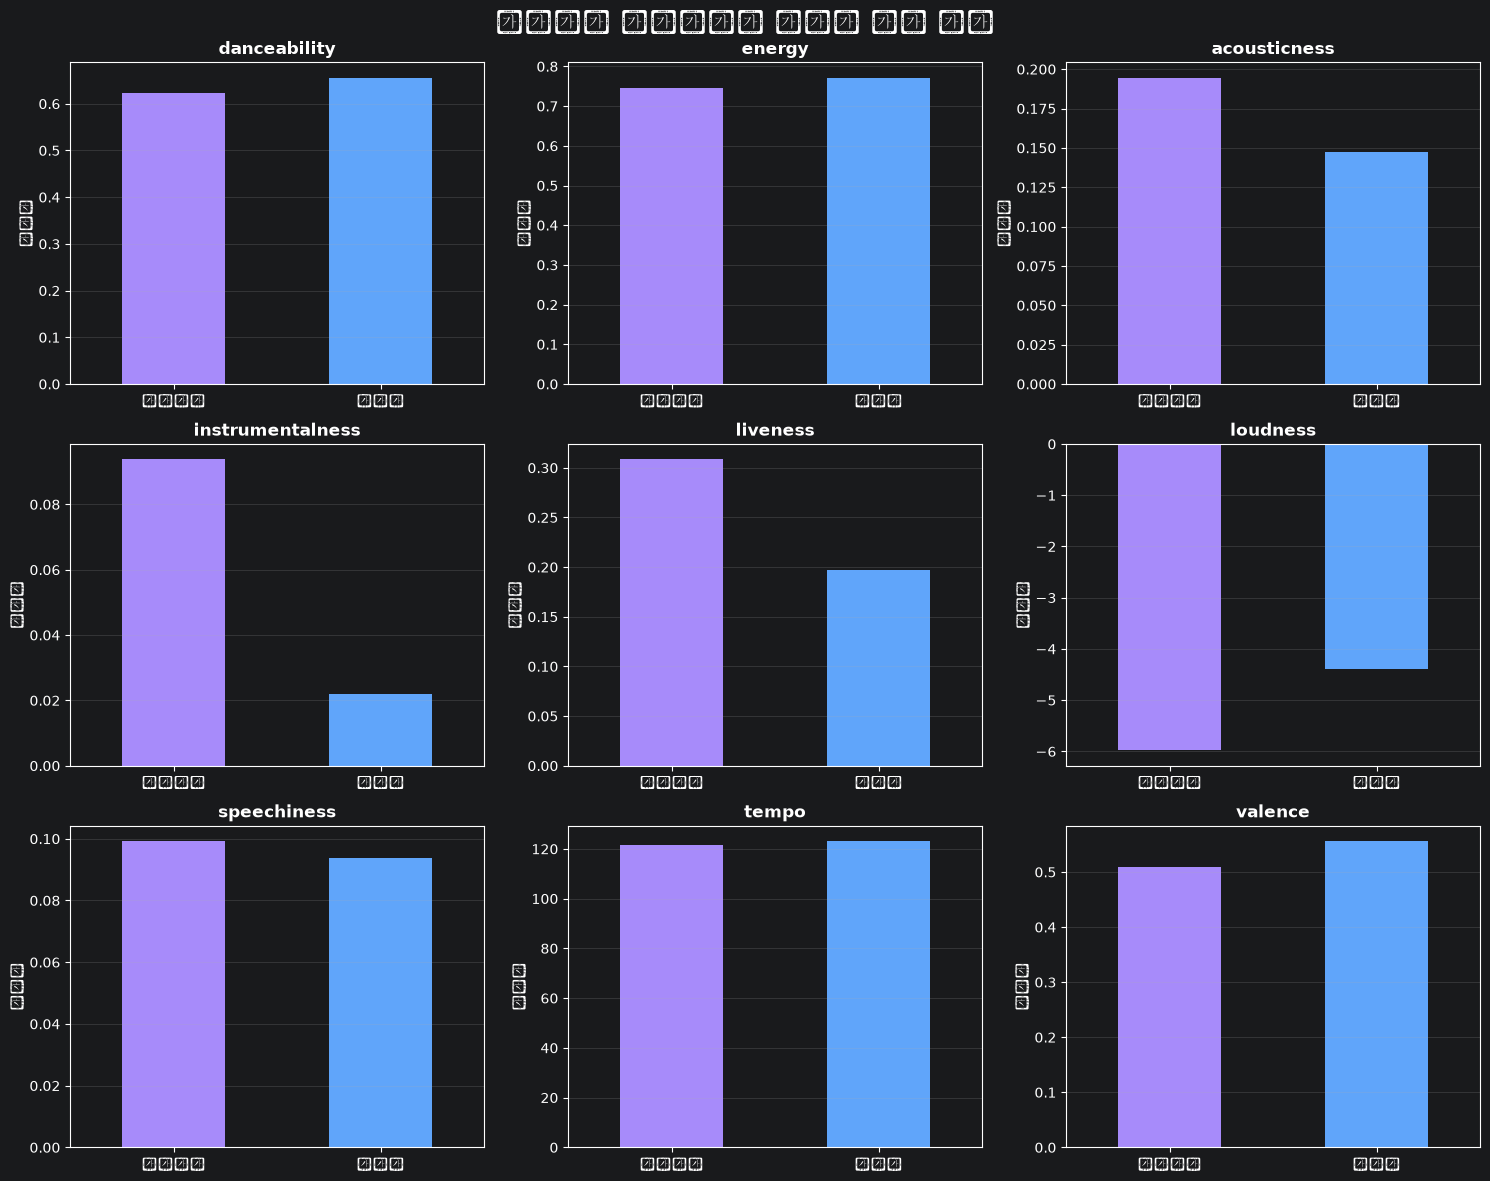

In [51]:
import matplotlib.pyplot as plt

features = [
    "danceability",
    "energy",
    "acousticness",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence"
]

colors = ["#A78BFA", "#60A5FA"]  # 보라색, 파란색

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, feature in zip(axes.flat, features):
    group_mean[feature].plot(
        kind="bar",
        ax=ax,
        color=colors
    )

    ax.set_title(feature, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("평균값")
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", alpha=0.25)

plt.suptitle(
    "인기곡과 비인기곡의 음악적 특성 비교",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [52]:
correlation = analysis_df[
    [
        "popularity",
        "danceability",
        "energy",
        "acousticness",
        "instrumentalness",
        "liveness",
        "loudness",
        "speechiness",
        "tempo",
        "valence"
    ]
].corr()["popularity"].sort_values(ascending=False)

correlation

popularity          1.000000
loudness            0.347283
danceability        0.124577
valence             0.124318
energy              0.123740
tempo               0.032080
speechiness        -0.045450
acousticness       -0.143537
liveness           -0.209063
instrumentalness   -0.233060
Name: popularity, dtype: float64

## -상관관계 분석 결과, loudness가 인기도와 가장 높은 양의 상관관계(0.347)를 보였다. 반면 instrumentalness(-0.233), liveness(-0.209), acousticness(-0.144)는 약한 음의 상관관계를 보였다. tempo(0.032)와 speechiness(-0.045)는 인기도와 거의 관계가 없었다. 다만 모든 상관계수의 절댓값이 크지 않으므로, 음악적 특성만으로 인기도를 강하게 설명하기는 어렵다.

C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2828699792.py:23: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2828699792.py:23: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2828699792.py:23: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2828699792.py:23: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2828699792.py:23: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2828699792.py:23: UserWarning: Glyph 50501 (\N{HANGUL SYLLABLE AG}) missing from font(s) DejaVu S

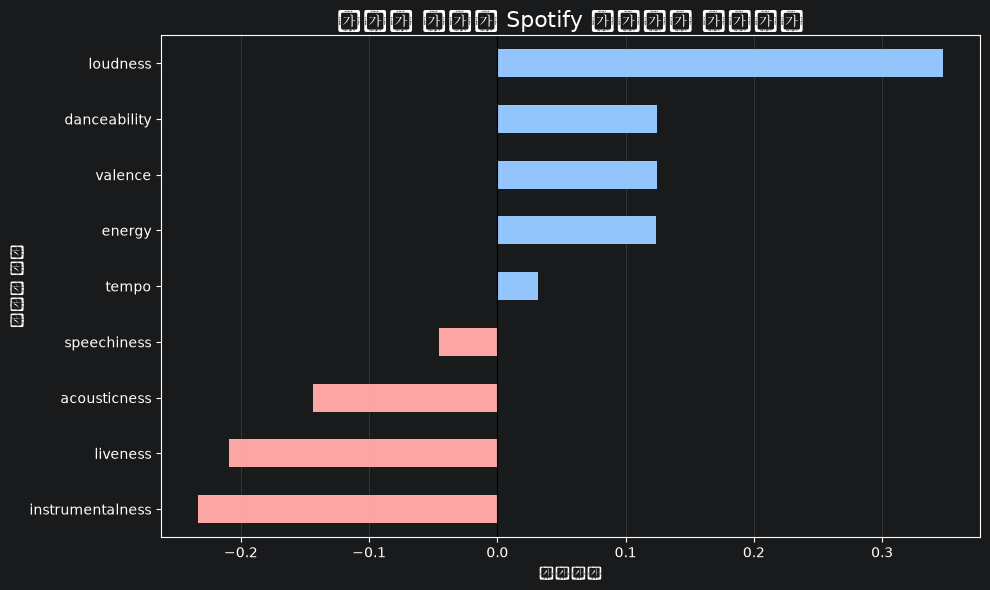

In [53]:
import matplotlib.pyplot as plt

# popularity 자기 자신과의 상관관계는 제외
corr_features = correlation.drop("popularity").sort_values()

colors = [
    "#FCA5A5" if value < 0 else "#93C5FD"
    for value in corr_features
]

plt.figure(figsize=(10, 6))

corr_features.plot(
    kind="barh",
    color=colors
)

plt.axvline(0, color="black", linewidth=0.8)
plt.title("음악적 특성과 Spotify 인기도의 상관관계", fontsize=16)
plt.xlabel("상관계수")
plt.ylabel("음악적 특성")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\1801624304.py:16: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\1801624304.py:16: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\1801624304.py:16: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\1801624304.py:16: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\1801624304.py:16: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\1801624304.py:16: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.

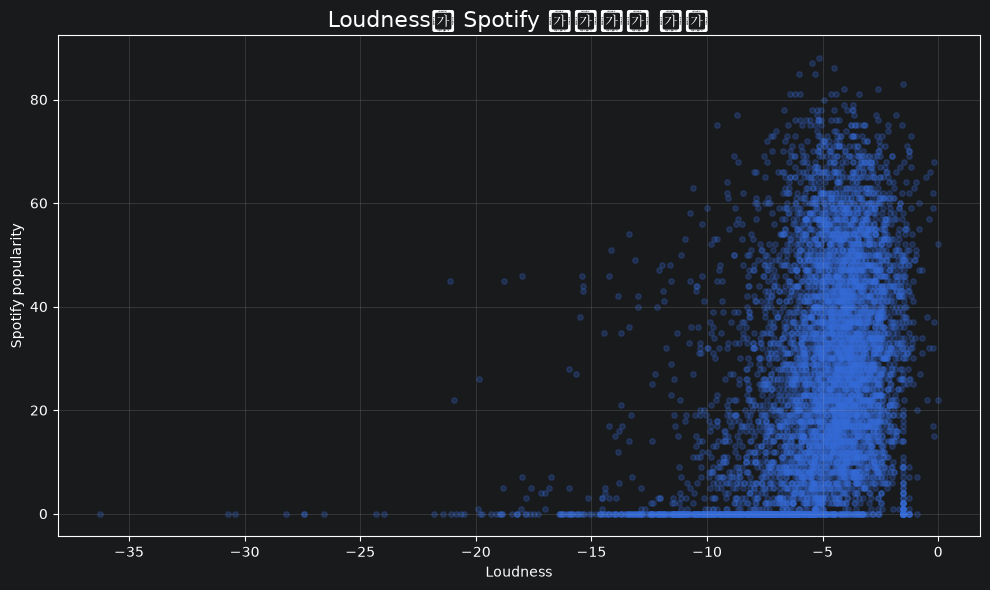

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    analysis_df["loudness"],
    analysis_df["popularity"],
    alpha=0.25,
    s=15
)

plt.title("Loudness와 Spotify 인기도의 관계", fontsize=16)
plt.xlabel("Loudness")
plt.ylabel("Spotify popularity")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## - Loudness와 Spotify 인기도의 산점도를 확인한 결과, loudness가 높아질수록 인기도가 증가하는 약한 경향이 나타났다. 그러나 데이터가 넓게 분포하고 인기도가 0인 곡도 많아, loudness만으로 인기도를 정확하게 설명하기는 어려웠다.

C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2078995561.py:36: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2078995561.py:36: UserWarning: Glyph 50501 (\N{HANGUL SYLLABLE AG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2078995561.py:36: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2078995561.py:36: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2078995561.py:36: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\2078995561.py:36: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaV

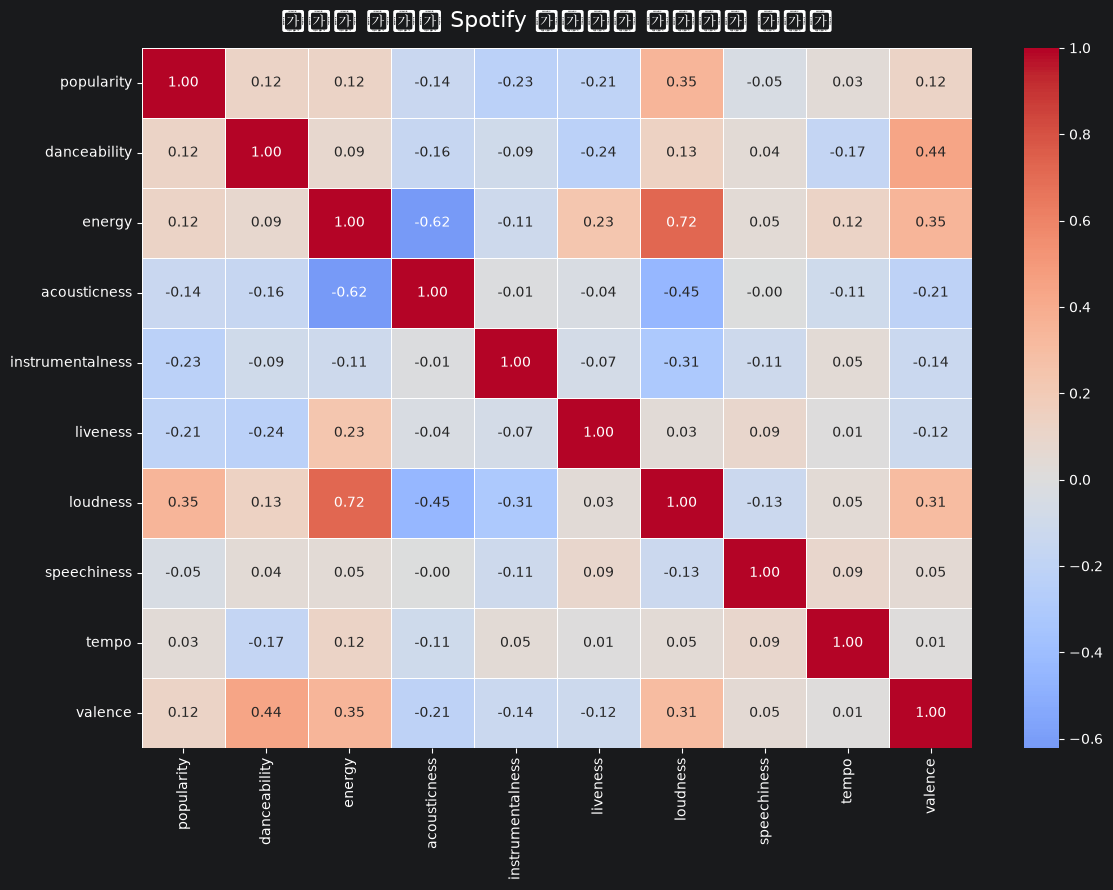

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_data = analysis_df[
    [
        "popularity",
        "danceability",
        "energy",
        "acousticness",
        "instrumentalness",
        "liveness",
        "loudness",
        "speechiness",
        "tempo",
        "valence"
    ]
].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "음악적 특성과 Spotify 인기도의 상관관계 히트맵",
    fontsize=16,
    pad=15
)

plt.tight_layout()
plt.show()

In [56]:
difference = group_mean.loc["인기곡"] - group_mean.loc["비인기곡"]

difference = difference.sort_values(ascending=False)

difference

tempo               1.780914
loudness            1.586100
valence             0.046502
danceability        0.033069
energy              0.025702
speechiness        -0.005378
acousticness       -0.047501
instrumentalness   -0.071799
liveness           -0.111945
dtype: float64

C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\1633361403.py:26: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\1633361403.py:26: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\1633361403.py:26: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\1633361403.py:26: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\1633361403.py:26: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Qeen\AppData\Local\Temp\ipykernel_384\1633361403.py:26: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu 

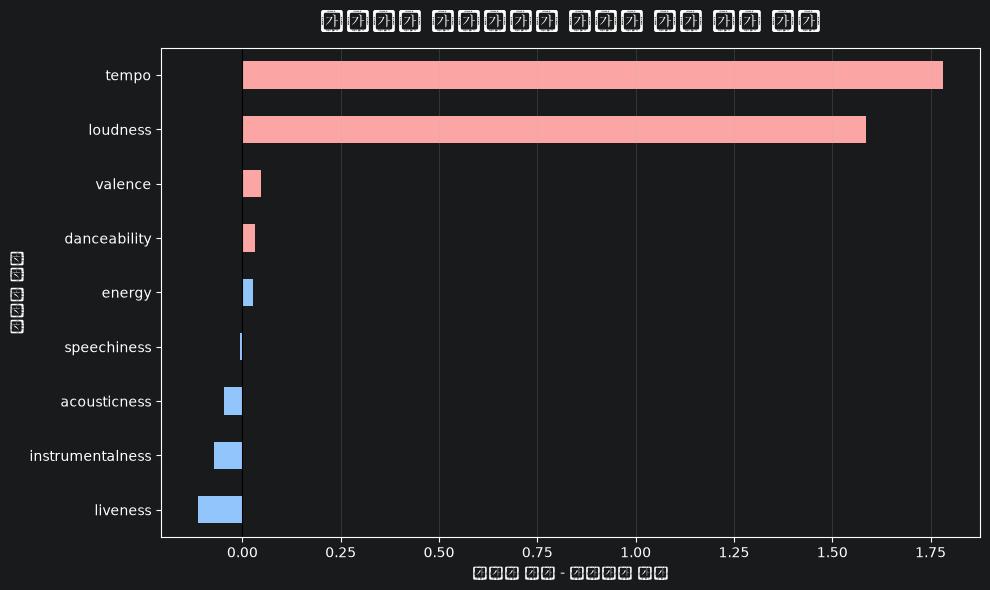

In [57]:
import matplotlib.pyplot as plt

colors = [
    "#93C5FD" if value >= 0 else "#FCA5A5"
    for value in difference
]

plt.figure(figsize=(10, 6))

difference.sort_values().plot(
    kind="barh",
    color=colors
)

plt.axvline(0, color="black", linewidth=0.8)

plt.title(
    "인기곡과 비인기곡의 음악적 특성 평균 차이",
    fontsize=16,
    pad=15
)

plt.xlabel("인기곡 평균 - 비인기곡 평균")
plt.ylabel("음악적 특성")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## - 인기곡과 비인기곡의 평균을 비교한 결과, 특히 tempo와 loudness에서 상대적으로 큰 차이가 나타났다. 그러나 상관관계 분석에서는 loudness가 인기도와 가장 뚜렷한 양의 관계를 보였고, tempo의 상관관계는 매우 약했다. 따라서 음악적 특성 중 일부는 인기도와 관련이 있을 수 있지만, 이러한 특성이 인기도의 원인이라고 단정할 수는 없다.

In [58]:
year_popularity = (
    analysis_df
    .groupby("year")["popularity"]
    .mean()
)

year_popularity

year
2005    18.181818
2006    23.892857
2007    16.128571
2008    17.364486
2009    19.048077
2010    19.434343
2011    18.270000
2012    21.389189
2013    16.649660
2014    22.761589
2015    20.498801
2016    21.760976
2017    25.148077
2018    27.854232
2019    30.109259
2020    34.488255
2021    34.509658
2022    35.673145
2023    32.317919
2024    32.529680
Name: popularity, dtype: float64

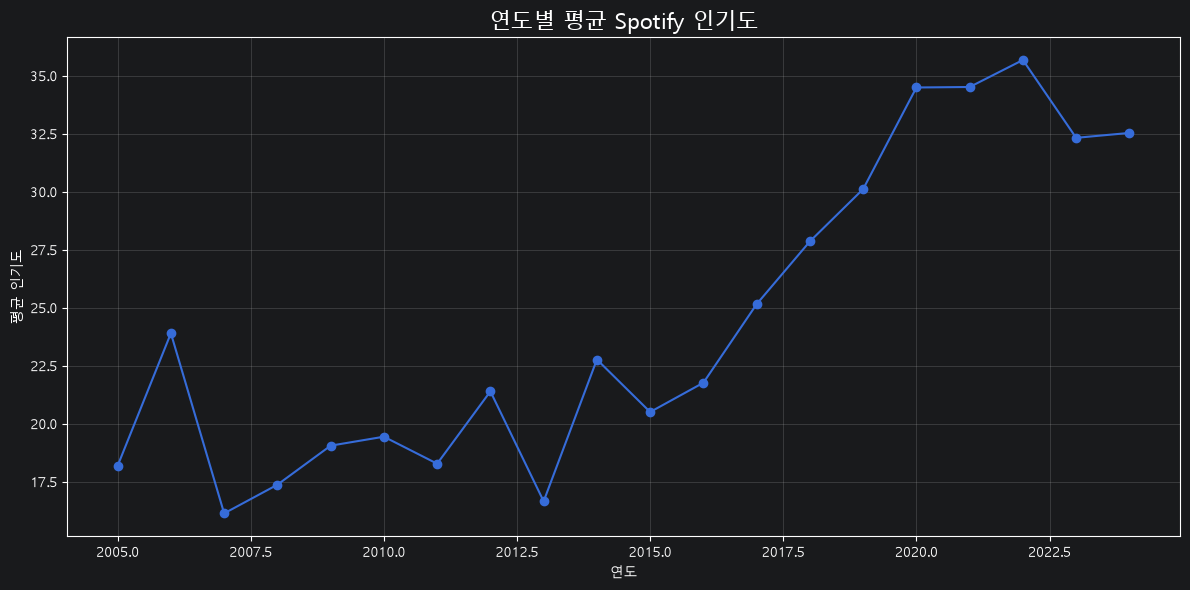

In [60]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정
mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12, 6))

year_popularity.plot(kind="line", marker="o")

plt.title("연도별 평균 Spotify 인기도", fontsize=16)
plt.xlabel("연도")
plt.ylabel("평균 인기도")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

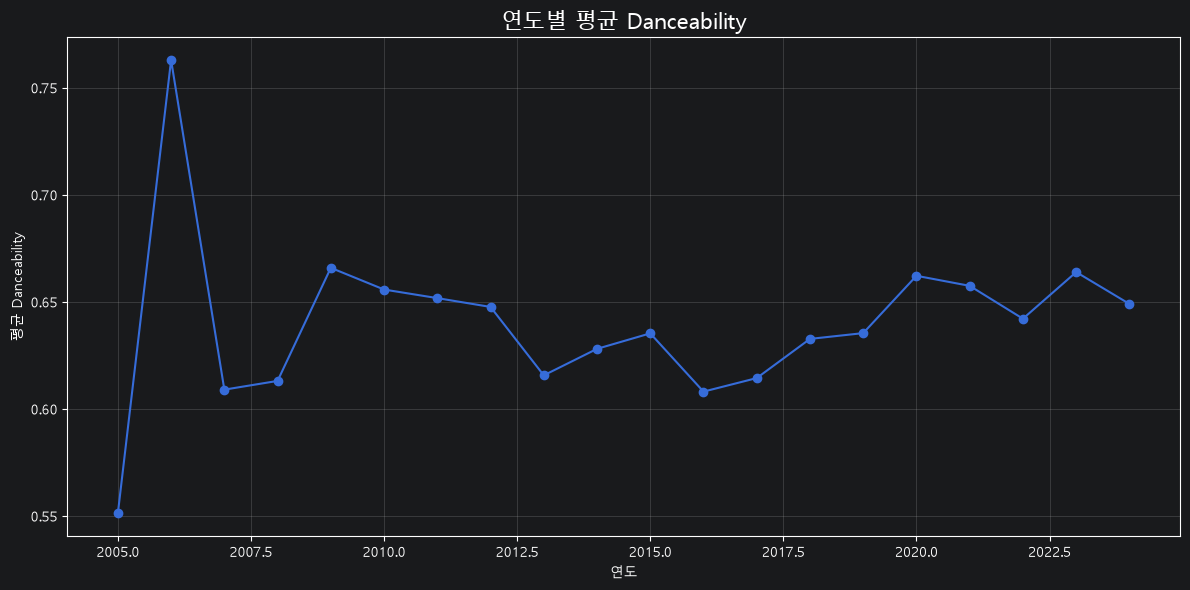

In [61]:
year_danceability = (
    analysis_df
    .groupby("year")["danceability"]
    .mean()
)

plt.figure(figsize=(12, 6))

year_danceability.plot(kind="line", marker="o")

plt.title("연도별 평균 Danceability", fontsize=16)
plt.xlabel("연도")
plt.ylabel("평균 Danceability")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

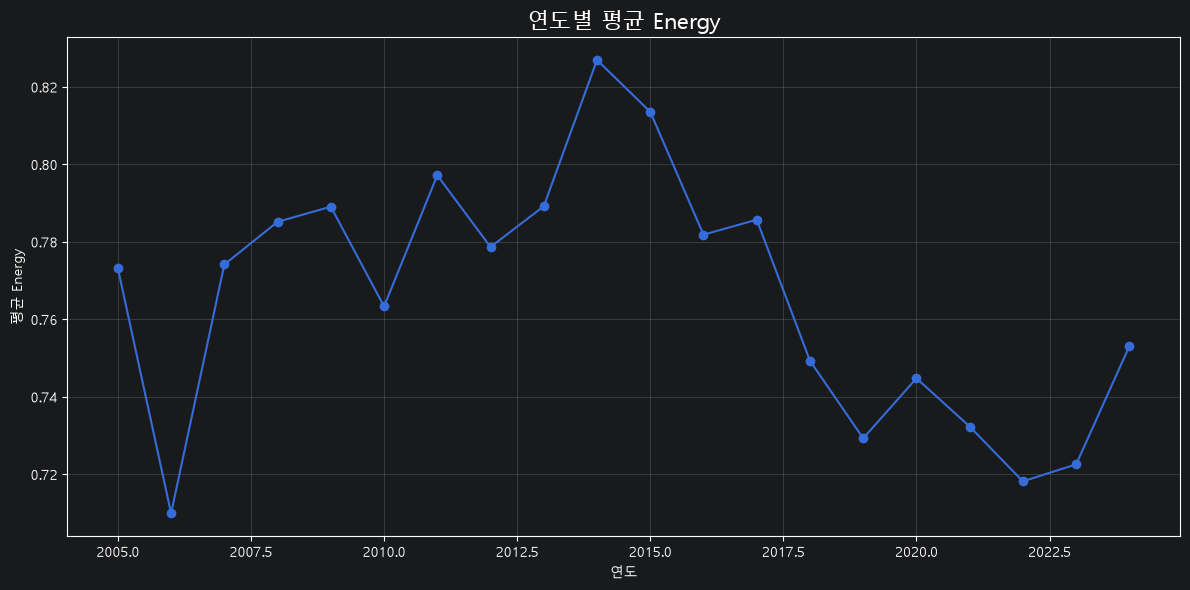

In [62]:
year_energy = (
    analysis_df
    .groupby("year")["energy"]
    .mean()
)

plt.figure(figsize=(12, 6))

year_energy.plot(kind="line", marker="o")

plt.title("연도별 평균 Energy", fontsize=16)
plt.xlabel("연도")
plt.ylabel("평균 Energy")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

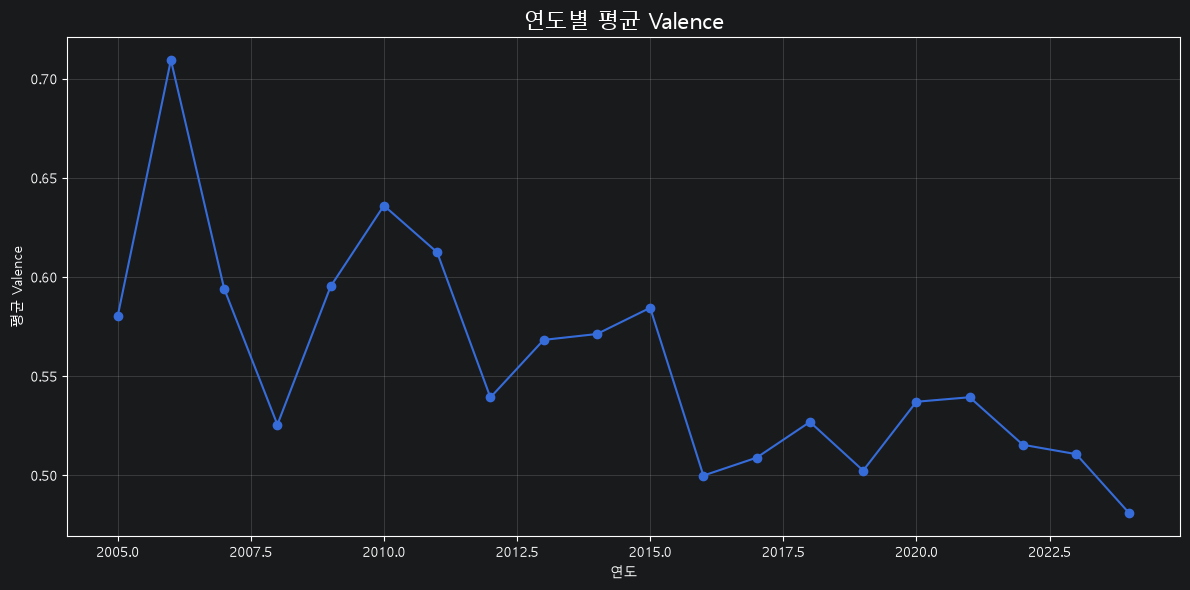

In [63]:
year_valence = (
    analysis_df
    .groupby("year")["valence"]
    .mean()
)

plt.figure(figsize=(12, 6))

year_valence.plot(kind="line", marker="o")

plt.title("연도별 평균 Valence", fontsize=16)
plt.xlabel("연도")
plt.ylabel("평균 Valence")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

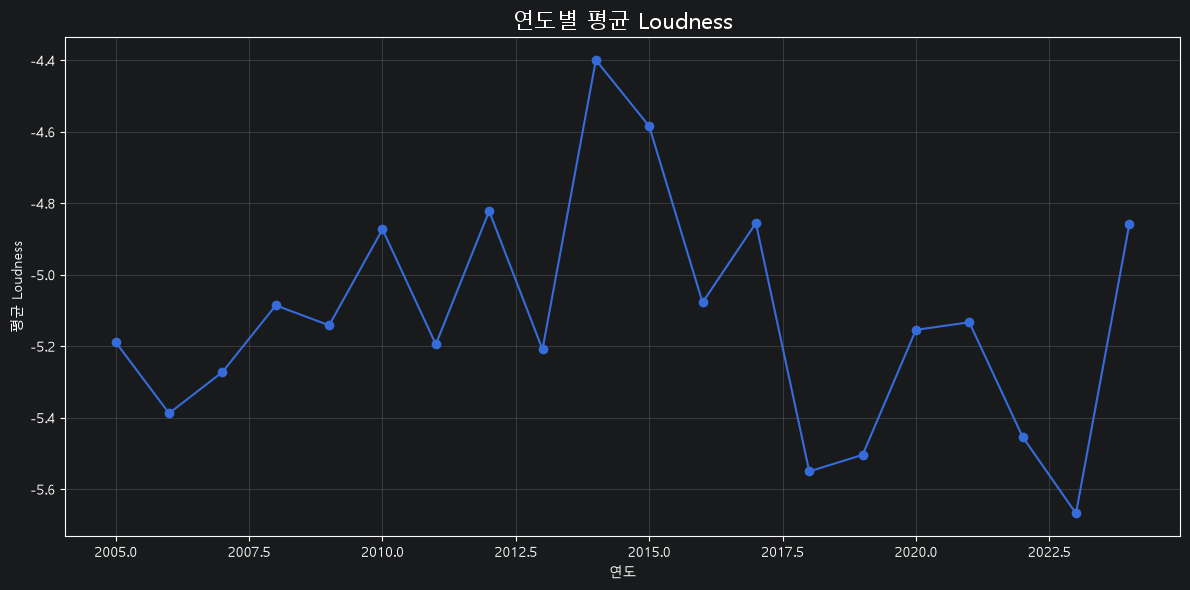

In [64]:
year_loudness = (
    analysis_df
    .groupby("year")["loudness"]
    .mean()
)

plt.figure(figsize=(12, 6))

year_loudness.plot(kind="line", marker="o")

plt.title("연도별 평균 Loudness", fontsize=16)
plt.xlabel("연도")
plt.ylabel("평균 Loudness")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
year_group = (
    analysis_df
    .groupby(["year", "popularity_group"])
    .size()
    .unstack(fill_value=0)
)

year_group

popularity_group,비인기곡,인기곡
year,,
2005,17,5
2006,19,9
2007,56,14
2008,75,32
2009,73,31
2010,70,29
2011,149,51
2012,128,57
2013,222,72


In [66]:
year_ratio = (
    year_group
    .div(year_group.sum(axis=1), axis=0)
    .mul(100)
)

year_ratio

popularity_group,비인기곡,인기곡
year,,
2005,77.272727,22.727273
2006,67.857143,32.142857
2007,80.000000,20.000000
2008,70.093458,29.906542
2009,70.192308,29.807692
2010,70.707071,29.292929
2011,74.500000,25.500000
2012,69.189189,30.810811
2013,75.510204,24.489796


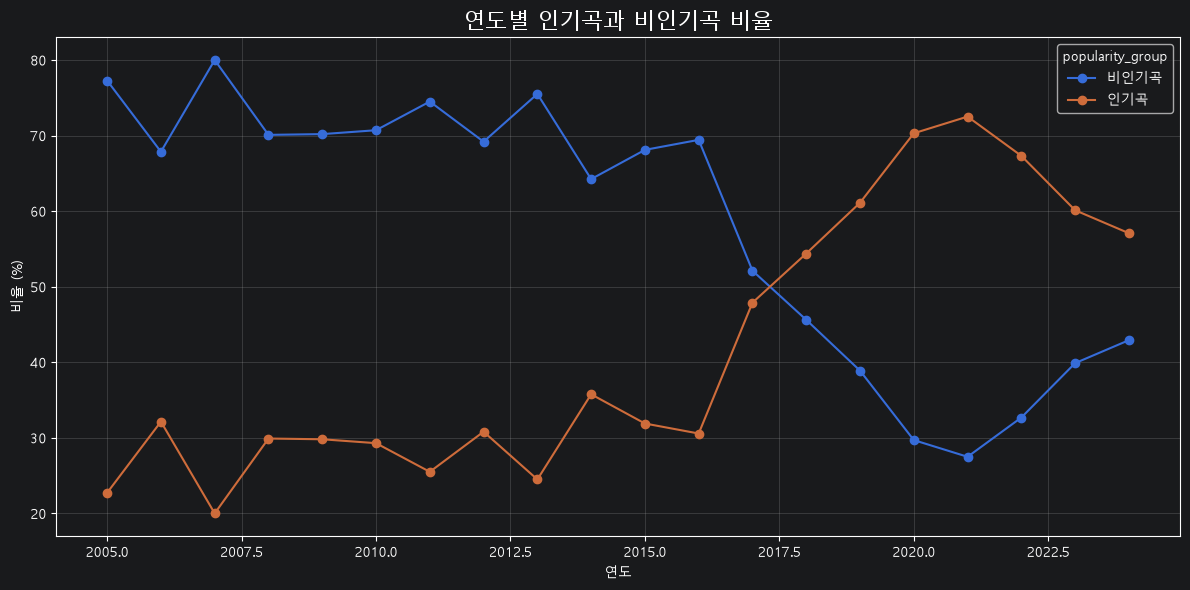

In [67]:
year_ratio.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("연도별 인기곡과 비인기곡 비율", fontsize=16)
plt.xlabel("연도")
plt.ylabel("비율 (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
artist_count = (
    analysis_df
    .groupby("artist_name")
    .size()
)

artist_count

artist_name
22PM, Poor Bass Love           2
2PM                          421
2PM, Artento Divini            1
2PM, BOYTOY                    2
2PM, Buzz & Flipswitch         1
                            ... 
iKON, P.K (FUTURE BOUNCE)      1
iKON, RAE SEONG CHOE           2
iKon                          35
shinee                         3
wei                            1
Length: 224, dtype: int64

In [70]:
artist_5plus = artist_count[artist_count >= 5].index

artist_df = analysis_df[
    analysis_df["artist_name"].isin(artist_5plus)
].copy()

artist_df

,track_id,track_name,artist_name,album_name,year,popularity,danceability,energy,acousticness,instrumentalness,liveness,loudness,speechiness,tempo,valence,key,mode,time_signature,popularity_group
24523,5IAESfJjmOYu7cHyX557kz,Take Two,BTS,Take Two,2023,76,0.617,0.589,0.026800,0.000000,0.3780,-5.978,0.0345,92.991,0.566,7.0,1.0,4.0,인기곡
24524,4IJsVXbSeGPUrgwpVoHmlg,The Planet,BTS,The Planet,2023,65,0.665,0.848,0.000482,0.000000,0.2000,-3.619,0.0708,119.986,0.687,0.0,1.0,4.0,인기곡
24525,69xohKu8C1fsflYAiSNbwM,Run BTS,BTS,Proof,2022,78,0.724,0.818,0.020100,0.000000,0.0358,-3.747,0.1680,77.004,0.696,8.0,1.0,4.0,인기곡
24526,6jjYDGxVJsWS0a5wlVF5vS,Butter,BTS,Proof,2022,76,0.759,0.459,0.003230,0.000000,0.0788,-5.187,0.0948,109.997,0.695,8.0,1.0,4.0,인기곡
24527,10SRMwb9EuVS1K9rYsBfHQ,Yet To Come,BTS,Proof,2022,71,0.559,0.885,0.043200,0.000000,0.3330,-4.515,0.1890,172.029,0.683,1.0,1.0,4.0,인기곡
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35850,3JQJxRewX63qyISEfKMWSn,Coji De Portocale ( Cu aroma de Craciun - Exte...,BiBi,Coji de portocale (Cu aroma de Craciun) [Produ...,2016,0,0.793,0.520,0.096000,0.000000,0.0794,-7.759,0.1080,117.931,0.505,8.0,1.0,4.0,비인기곡
35851,2OoUOxtlxf7qqVVFziLKL3,Coji de portocale ( by Music Pink Elephant) - ...,BiBi,Coji de portocale ( by Music Pink Elephant) [P...,2016,2,0.804,0.519,0.375000,0.000002,0.4060,-7.479,0.0959,118.021,0.413,5.0,0.0,4.0,비인기곡
35852,4Vqal5XldhTbPiJ45zLq1c,Coji de portocale - Cu aroma de Craciun Extend...,BiBi,Coji de portocale (Cu aroma de Craciun - Produ...,2016,0,0.793,0.520,0.096000,0.000000,0.0794,-7.759,0.1080,117.931,0.505,8.0,1.0,4.0,비인기곡
35853,1bwXbfm8EqkbJUje93EpJb,Coji de portocale - Cu aroma de Craciun,BiBi,Coji de portocale (Cu aroma de Craciun - Produ...,2016,0,0.712,0.509,0.123000,0.000000,0.3870,-7.317,0.1210,117.747,0.477,8.0,1.0,4.0,비인기곡


In [71]:
artist_popularity = (
    artist_df
    .groupby("artist_name")["popularity"]
    .mean()
    .sort_values(ascending=False)
)

artist_popularity.head(10)

artist_name
NewJeans                       64.000000
LE SSERAFIM                    58.442623
ENHYPEN                        56.576471
TOMORROW X TOGETHER            53.887097
Stray Kids                     50.978417
BTS                            50.394872
TOMORROW X TOGETHER, Anitta    48.166667
ATEEZ                          47.973510
BLACKPINK                      46.328000
ITZY                           46.054545
Name: popularity, dtype: float64

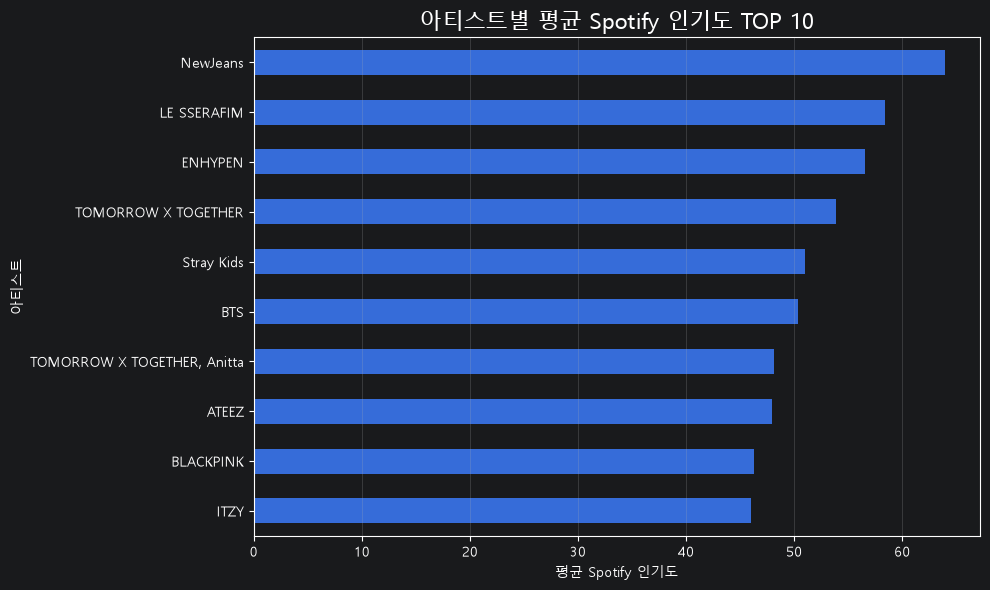

In [72]:
top10_artist = artist_popularity.head(10).sort_values()

plt.figure(figsize=(10, 6))

top10_artist.plot(kind="barh")

plt.title("아티스트별 평균 Spotify 인기도 TOP 10", fontsize=16)
plt.xlabel("평균 Spotify 인기도")
plt.ylabel("아티스트")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [73]:
artist_danceability = (
    artist_df[artist_df["artist_name"].isin(top10_artist.index)]
    .groupby("artist_name")["danceability"]
    .mean()
    .sort_values(ascending=False)
)

artist_danceability

artist_name
ITZY                           0.763327
TOMORROW X TOGETHER, Anitta    0.760667
NewJeans                       0.739656
LE SSERAFIM                    0.722016
Stray Kids                     0.670892
BLACKPINK                      0.664288
TOMORROW X TOGETHER            0.622258
BTS                            0.618015
ENHYPEN                        0.615659
ATEEZ                          0.586758
Name: danceability, dtype: float64

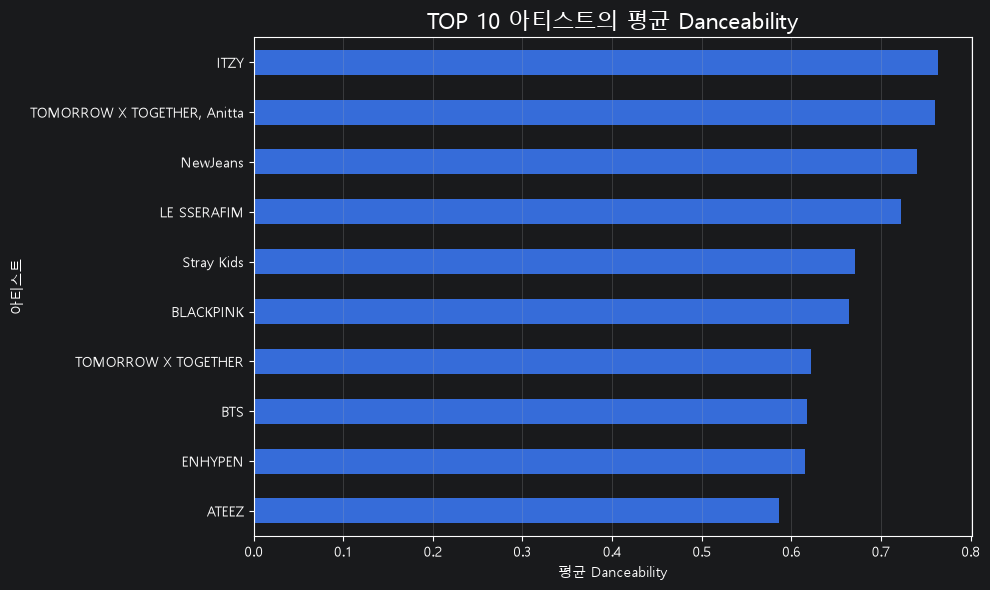

In [74]:
plt.figure(figsize=(10, 6))

artist_danceability.sort_values().plot(kind="barh")

plt.title("TOP 10 아티스트의 평균 Danceability", fontsize=16)
plt.xlabel("평균 Danceability")
plt.ylabel("아티스트")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [75]:
artist_energy = (
    artist_df[artist_df["artist_name"].isin(top10_artist.index)]
    .groupby("artist_name")["energy"]
    .mean()
    .sort_values(ascending=False)
)

artist_energy

artist_name
TOMORROW X TOGETHER, Anitta    0.847833
ITZY                           0.821582
ATEEZ                          0.794113
Stray Kids                     0.786752
LE SSERAFIM                    0.764754
BTS                            0.762213
ENHYPEN                        0.753365
BLACKPINK                      0.731888
TOMORROW X TOGETHER            0.711758
NewJeans                       0.622656
Name: energy, dtype: float64

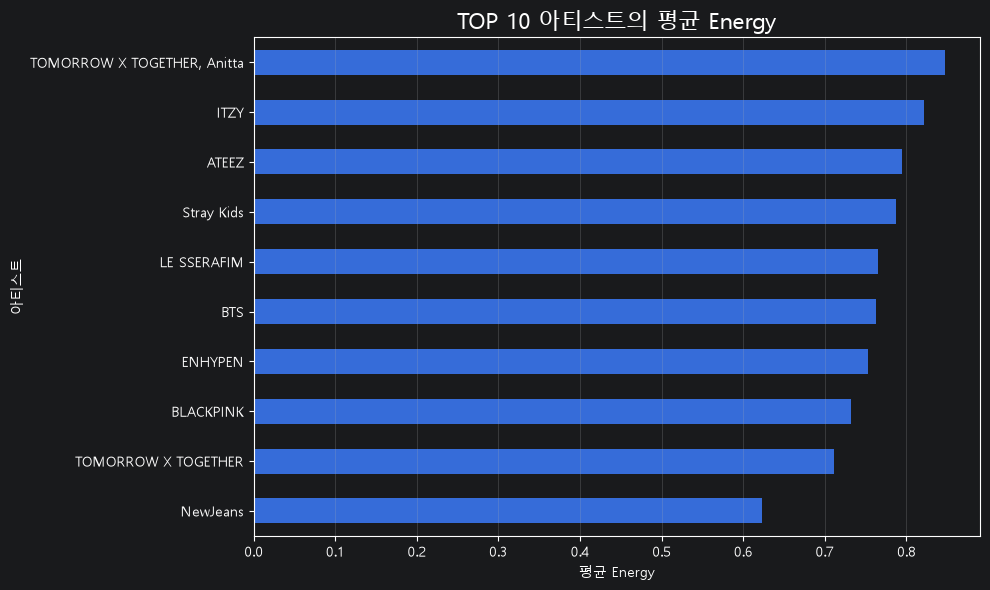

In [76]:
plt.figure(figsize=(10, 6))

artist_energy.sort_values().plot(kind="barh")

plt.title("TOP 10 아티스트의 평균 Energy", fontsize=16)
plt.xlabel("평균 Energy")
plt.ylabel("아티스트")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [77]:
artist_valence = (
    artist_df[artist_df["artist_name"].isin(top10_artist.index)]
    .groupby("artist_name")["valence"]
    .mean()
    .sort_values(ascending=False)
)

artist_valence

artist_name
TOMORROW X TOGETHER, Anitta    0.843667
ITZY                           0.646191
LE SSERAFIM                    0.607984
ENHYPEN                        0.577386
NewJeans                       0.551344
BTS                            0.536975
BLACKPINK                      0.514392
Stray Kids                     0.513939
TOMORROW X TOGETHER            0.495318
ATEEZ                          0.455674
Name: valence, dtype: float64

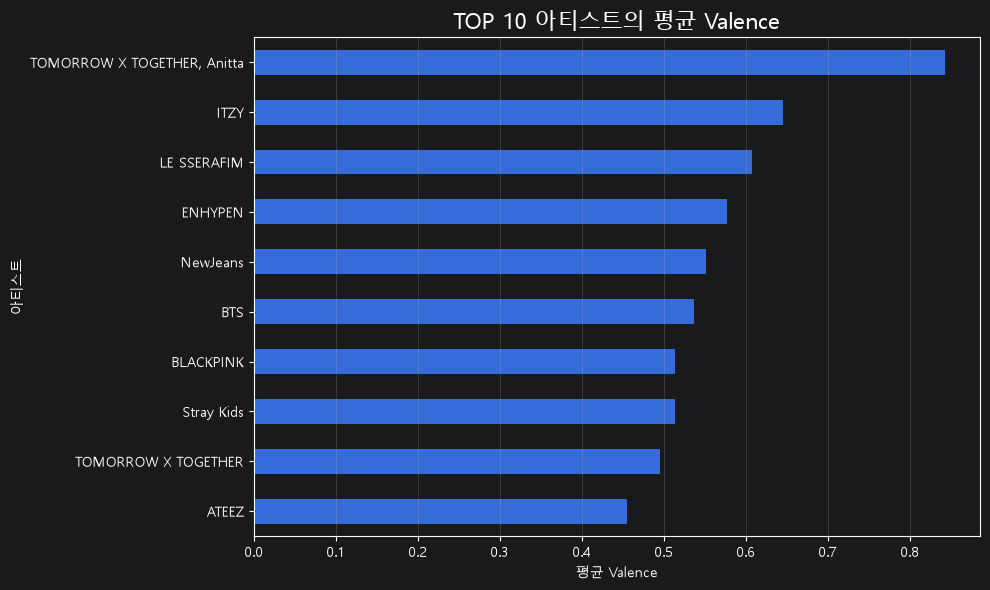

In [78]:
plt.figure(figsize=(10, 6))

artist_valence.sort_values().plot(kind="barh")

plt.title("TOP 10 아티스트의 평균 Valence", fontsize=16)
plt.xlabel("평균 Valence")
plt.ylabel("아티스트")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [79]:
artist_loudness = (
    artist_df[artist_df["artist_name"].isin(top10_artist.index)]
    .groupby("artist_name")["loudness"]
    .mean()
    .sort_values(ascending=False)
)

artist_loudness

artist_name
ITZY                          -3.805900
TOMORROW X TOGETHER, Anitta   -3.910833
Stray Kids                    -4.293439
ENHYPEN                       -4.934576
ATEEZ                         -5.081623
LE SSERAFIM                   -5.083836
BTS                           -5.313323
TOMORROW X TOGETHER           -5.370444
BLACKPINK                     -5.399544
NewJeans                      -6.163531
Name: loudness, dtype: float64

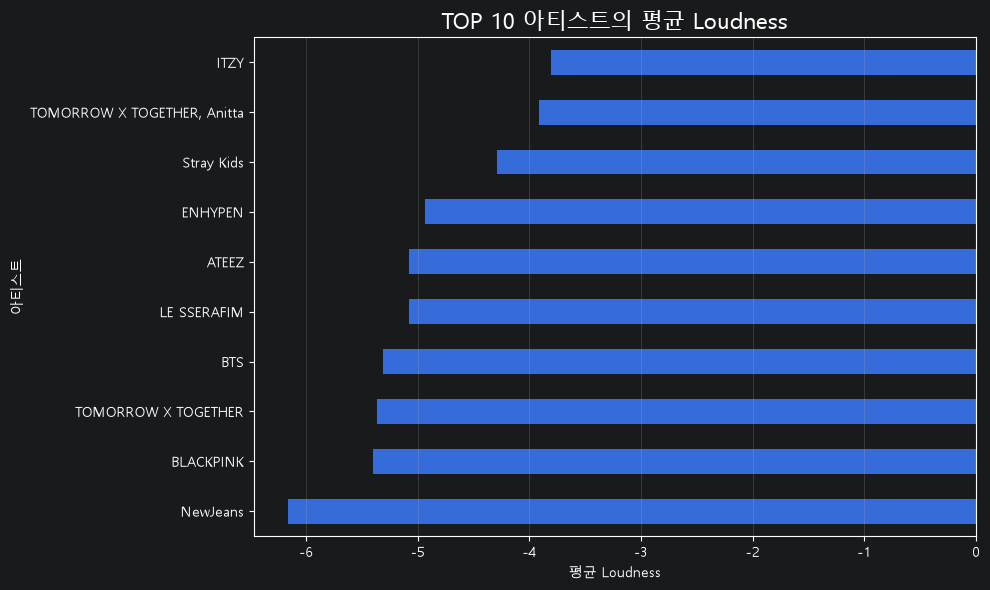

In [80]:
plt.figure(figsize=(10, 6))

artist_loudness.sort_values().plot(kind="barh")

plt.title("TOP 10 아티스트의 평균 Loudness", fontsize=16)
plt.xlabel("평균 Loudness")
plt.ylabel("아티스트")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [81]:
artist_features = pd.DataFrame({
    "평균 인기도": artist_popularity.head(10),
    "Danceability": artist_danceability,
    "Energy": artist_energy,
    "Valence": artist_valence,
    "Loudness": artist_loudness
})

artist_features

,평균 인기도,Danceability,Energy,Valence,Loudness
artist_name,,,,,
ATEEZ,47.973510,0.586758,0.794113,0.455674,-5.081623
BLACKPINK,46.328000,0.664288,0.731888,0.514392,-5.399544
BTS,50.394872,0.618015,0.762213,0.536975,-5.313323
ENHYPEN,56.576471,0.615659,0.753365,0.577386,-4.934576
ITZY,46.054545,0.763327,0.821582,0.646191,-3.805900
LE SSERAFIM,58.442623,0.722016,0.764754,0.607984,-5.083836
NewJeans,64.000000,0.739656,0.622656,0.551344,-6.163531
Stray Kids,50.978417,0.670892,0.786752,0.513939,-4.293439
TOMORROW X TOGETHER,53.887097,0.622258,0.711758,0.495318,-5.370444


In [82]:
artist_features = artist_features.sort_values(
    "평균 인기도",
    ascending=False
)

artist_features

,평균 인기도,Danceability,Energy,Valence,Loudness
artist_name,,,,,
NewJeans,64.000000,0.739656,0.622656,0.551344,-6.163531
LE SSERAFIM,58.442623,0.722016,0.764754,0.607984,-5.083836
ENHYPEN,56.576471,0.615659,0.753365,0.577386,-4.934576
TOMORROW X TOGETHER,53.887097,0.622258,0.711758,0.495318,-5.370444
Stray Kids,50.978417,0.670892,0.786752,0.513939,-4.293439
BTS,50.394872,0.618015,0.762213,0.536975,-5.313323
"TOMORROW X TOGETHER, Anitta",48.166667,0.760667,0.847833,0.843667,-3.910833
ATEEZ,47.973510,0.586758,0.794113,0.455674,-5.081623
BLACKPINK,46.328000,0.664288,0.731888,0.514392,-5.399544


In [83]:
artist_correlation = artist_features.corr(numeric_only=True)

artist_correlation["평균 인기도"].sort_values(ascending=False)

평균 인기도          1.000000
Danceability    0.103946
Valence        -0.123011
Loudness       -0.618035
Energy         -0.737561
Name: 평균 인기도, dtype: float64

# 질문 1

## 인기 있는 한국어 노래는 어떤 음악적 특징을 가지고 있을까?

우리가 인기곡 vs 비인기곡 평균을 비교했을 때:

인기곡 → Danceability ↑
인기곡 → Energy ↑
인기곡 → Valence ↑
인기곡 → Loudness ↑
인기곡 → Tempo ↑
인기곡 → Acousticness ↓
인기곡 → Instrumentalness ↓
인기곡 → Liveness ↓
Speechiness → 거의 차이 없음

따라서

인기곡은 비인기곡보다 평균적으로 춤추기 쉽고, 에너지가 높으며, 밝은 분위기를 보였다. 또한 상대적으로 음량이 크고 템포가 빠른 경향이 나타났다. 반면 어쿠스틱·연주곡·라이브 녹음 성향은 낮게 나타났다.

# 질문 2
## 음악적 특성과 Spotify 인기도 사이에는 어떤 관계가 있을까?

6887곡 전체의 상관관계를 사용하였다

가장 눈에 띄는 건

Loudness → 0.347

그리고

Instrumentalness → -0.233
Liveness → -0.209
Acousticness → -0.144

나머지는 대부분 플러스와 마이너스 0.13 이하였다

따라서

음악적 특성과 Spotify 인기도 사이에는 일부 관련성이 나타났다. 특히 loudness는 인기도와 가장 높은 양의 상관관계(0.347)를 보였으며, instrumentalness와 liveness는 약한 음의 상관관계를 보였다. 그러나 대부분의 상관계수가 크지 않아 음악적 특성과 인기도 사이의 관계는 전반적으로 강하지 않은 것으로 나타났다

# 질문 3
## 음악적 특성만으로 인기곡과 비인기곡을 구분할 수 있을까?

함부로 구분할 수 있다고는 말 못할것같다

내가 한 건 평균 비교와 상관관계 분석이고 실제로 예측 모델? 은 분석을 안했기 때문..

음악적 특성에 따라 인기곡과 비인기곡 사이에 일부 차이는 나타났지만, 음악적 특성만으로 인기 여부를 명확하게 구분할 수 있다고 판단하기는 어렵다. Spotify 인기도에는 음악적 특성 외에도 아티스트의 인지도, 발매 시기, 곡의 노출 정도 등 다양한 요인이 영향을 줄 수 있기 때문이다.

# 결론
본 분석에서는 Spotify에서 한국어로 분류된 2005~2024년 음악 6887곡을 대상으로 음악적 특성과 인기도의 관계를 분석하였다.
인기곡은 비인기곡에 비해 평균적으로 높은 Danceability, Energy, Valence, Loudness와 약간 빠른 Tempo를 보였다.
상관관계 분석에서는 Loudness가 Spotify 인기도와 가장 높은 양의 상관관계를 나타냈으며, Instrumentalness와 Liveness는 음의 상관관계를 보였다.
그러나 대부분의 상관관계가 크지 않아
음악적 특성만으로 Spotify 인기도를 설명하거나 인기 여부를 명확하게 구분하기에는 한계가 있었다.

In [84]:
result_table = pd.DataFrame({
    "인기곡 평균": group_mean.loc["인기곡"],
    "비인기곡 평균": group_mean.loc["비인기곡"],
    "평균 차이": difference,
    "인기도 상관계수": correlation.drop("popularity")
})

result_table

,인기곡 평균,비인기곡 평균,평균 차이,인기도 상관계수
acousticness,0.147122,0.194623,-0.047501,-0.143537
danceability,0.655824,0.622755,0.033069,0.124577
energy,0.771638,0.745936,0.025702,0.123740
instrumentalness,0.022008,0.093807,-0.071799,-0.233060
liveness,0.196625,0.308570,-0.111945,-0.209063
loudness,-4.394127,-5.980227,1.586100,0.347283
speechiness,0.093903,0.099281,-0.005378,-0.045450
tempo,123.180747,121.399833,1.780914,0.032080
valence,0.556396,0.509894,0.046502,0.124318


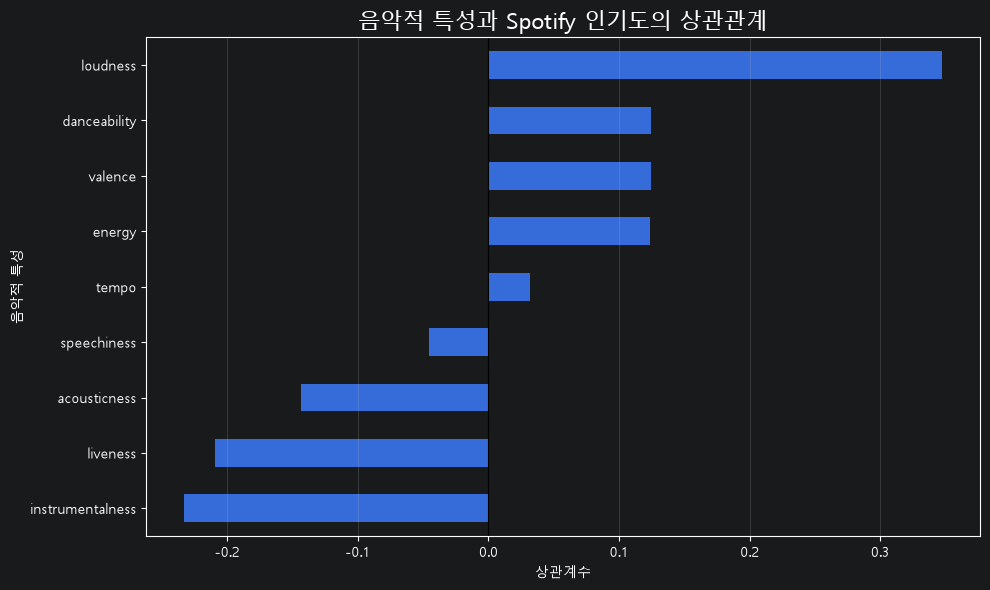

In [85]:
corr_result = result_table["인기도 상관계수"].sort_values()

plt.figure(figsize=(10, 6))

corr_result.plot(kind="barh")

plt.axvline(0, color="black", linewidth=0.8)

plt.title("음악적 특성과 Spotify 인기도의 상관관계", fontsize=16)
plt.xlabel("상관계수")
plt.ylabel("음악적 특성")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

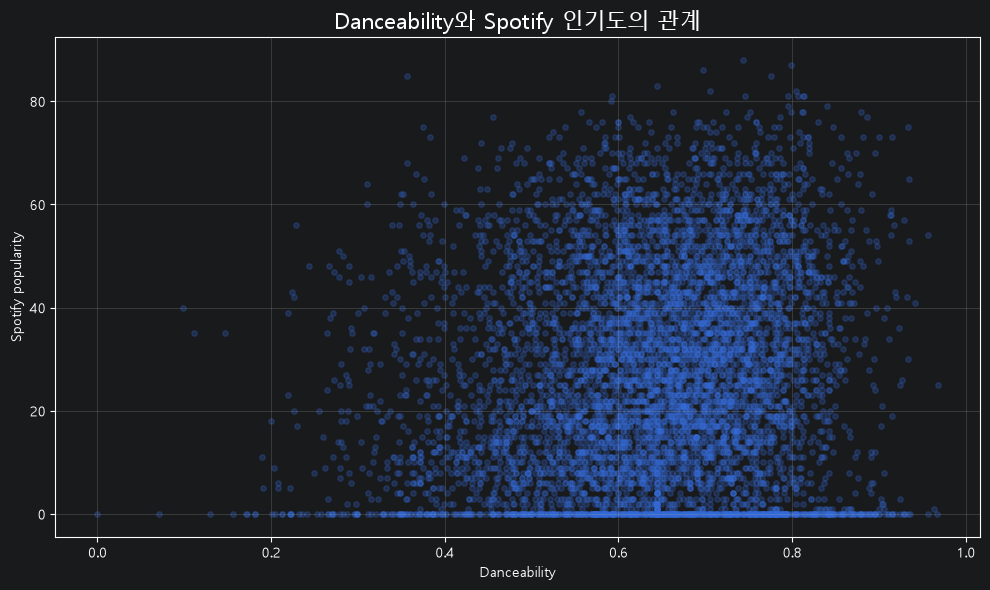

In [86]:
plt.figure(figsize=(10, 6))

plt.scatter(
    analysis_df["danceability"],
    analysis_df["popularity"],
    alpha=0.25,
    s=15
)

plt.title("Danceability와 Spotify 인기도의 관계", fontsize=16)
plt.xlabel("Danceability")
plt.ylabel("Spotify popularity")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

머신러닝을 제외하고

음악적 특성과 인기도 사이에 통계적인 차이와 일부 상관관계는 확인되었지만, 각 특성의 상관관계가 전반적으로 크지 않고 데이터가 넓게 분포되어 있어 음악적 특성만으로 인기 여부를 명확하게 구분하기에는 한계가 있었다